# Deadzone — scratch query surface

**This is not a deliverable.** Findings live in `report/writeup.md` and the
dashboard (`dashboard/`); nothing in this notebook is a citable result. This
exists so that in a live conversation — "does that hold for engine noise too?",
"what does u17 look like under heavy reverb?" — the answer is a 10-second query
against real data instead of "I'd have to check."

Every cell below runs offline against `results/master.csv` (the 10,560-row real
grid, three model arms) and `results/dead_zones.csv`. No network, no API key, no
writes to `results/`. Run top to bottom, or jump straight to a question — each
question cell is self-contained given the helpers defined earlier in the
notebook.

In [1]:
from __future__ import annotations
import csv, json, os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf

csv.field_size_limit(10**9)  # word_confidences / edits are large JSON blobs per row


def _find_root(start: Path, marker: str = "results/master.csv", max_up: int = 5) -> Path:
    '''Walk up from the notebook's cwd to find the repo root, so this notebook
    runs the same whether launched from notebooks/ (Jupyter's default) or the
    repo root itself.'''
    p = start.resolve()
    for _ in range(max_up):
        if (p / marker).exists():
            return p
        p = p.parent
    raise FileNotFoundError(f"couldn't find repo root (looked for {marker!r} above {start})")


ROOT = _find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))  # so `import deadzone.*` works regardless of cwd

master = pd.read_csv(ROOT / "results" / "master.csv", engine="python")
dead_zones = pd.read_csv(ROOT / "results" / "dead_zones.csv")

# Canonical "did this clip produce anything scorable" flag. Deliberately NOT
# `mean_conf.isna()` -- see the facts cell right below for why that's unsafe.
# Matches deadzone/analysis/__init__.py::is_silent_row (n_hyp = n_ref - n_del + n_ins).
master["n_hyp_words"] = master["n_ref"] - master["n_del"] + master["n_ins"]
master["is_silent"] = master["failed"] | (master["n_hyp_words"].fillna(0) <= 0)

print(f"master:     {master.shape[0]:,} rows x {master.shape[1]} cols")
print(f"            models: {dict(master['model'].value_counts())}")
print(f"            {master['clip_id'].nunique()} clips, {master['condition_name'].nunique()} conditions")
print(f"dead_zones: {dead_zones.shape[0]} rows  {dict(dead_zones['category'].value_counts())}")

master:     10,560 rows x 28 cols
            models: {'nova-3': np.int64(7040), 'whisper-base': np.int64(1760), 'elevenlabs-scribe': np.int64(1760)}
            40 clips, 176 conditions
dead_zones: 96 rows  {'dead_zone': np.int64(78), 'mute_zone': np.int64(14), 'silence_driven': np.int64(4)}


## Facts to know before querying (verified against this table, not assumed)

- **`mean_conf` is empty for silent (empty-transcript) rows, ALMOST always —
  but not by definition.** Of 10,557 non-failed rows, 2,624 produced zero
  scorable hypothesis words; 2,619 of those correctly have `mean_conf` NaN. The
  other **5 (all `whisper-base`) have a populated `mean_conf` — up to 0.926 —
  on zero scorable words**: vendor per-token confidence attaches to raw tokens
  (a lone `'.'`, or a run of decorative Unicode glyphs like `◑‿‿‿…`) that
  `normalize_text` collapses to nothing. `word_confidences` can be non-empty
  while every one of those "words" vanishes on normalization. **This is why
  the helpers below use `is_silent` (`n_ref - n_del + n_ins <= 0`, matching
  `deadzone/analysis/__init__.py::is_silent_row`), never `mean_conf.isna()`.**
  `elevenlabs-scribe` contributes none of those 5, but the rule is structural
  rather than per-vendor — keep using `is_silent` for it too. See Q3 for the
  concrete example (`u11`).
- **THREE models share this table and are NOT comparable on raw columns.**
  `nova-3`: 7,040 rows, all 40 clips x 176 conditions. `whisper-base`: 1,760
  rows (1,757 non-failed) and `elevenlabs-scribe`: 1,760 rows (0 failed) — both
  only the 10-clip active-learning subset x 176 conditions. Confidence scales
  are unrelated quantities across models — never plot them on one axis.
  **Less obviously: raw `wer` isn't comparable across models either** — nova-3's
  adapter disables `smart_format`/`punctuate`/`numerals` so its transcript is
  already word-form (`"four zero five"`), while Whisper writes digits and
  punctuation raw (`"405-912-717."`), which manufactures spurious
  deletions/insertions when scored against a spelled-out reference. Use
  `deadzone.cross_model_norm.cross_model_classify_errors` (or the precomputed
  `results/model_arms.json`) for any cross-model WER claim — see the bonus
  question at the bottom.
- **`elevenlabs-scribe` is RANK-ONLY — never put it in a cross-model WER
  comparison, normalized or not.** Its orthography is **non-deterministic**:
  four identical calls on byte-identical audio returned different transcripts on
  **5 of 6 probe clips** (`A7X42` vs `A seven X four two`; `Q9J05` vs `Q nine J
  zero five`; u33 flips the other way), worth up to **0.727 strict WER on
  identical input**. Whisper's offset is a *constant* (+0.090) that
  `cross_model_norm.py` characterizes once and subtracts; a per-call draw is
  variance, not bias, and cannot be subtracted. **The exclusion is enforced in
  code, not by convention** — `model_compare.compare_models` /
  `find_divergence_regions` RAISE on an incomparable arm unless the caller
  explicitly passes `exclude_incomparable=True`. Scribe *is* fully measured
  WITHIN itself (dead-zone flags, confidence shape, calibration), against its
  own distribution. One number to avoid quoting even so: its dead-zone **count**
  is not claimable in either scoring, because `dead_zone_flags` thresholds an
  *absolute* WER and Scribe's count moves 7 -> 0 of 176 between strict and
  normalized.
- **`rt60` is the REQUESTED reverb; `rir_rt60_measured` is what was actually
  delivered.** `AssetLibrary.resolve()` snaps each request to the nearest
  measured RIR, so e.g. every `rt60=0.45` row was actually rendered through a
  room measured at 0.474s. Regressions/joins on the acoustic cause should use
  `rir_rt60_measured` (or `rir_key`, the exact file), not `rt60`.

In [2]:
# Reference data used by a couple of the questions below (entity slots, ground truth)
with open(ROOT / "task_specs.json") as f:
    task_specs_raw = json.load(f)

from deadzone.agent_eval import TaskSpec, evaluate_task

task_specs = {cid: TaskSpec(slots=v["slots"], critical=tuple(v.get("critical", ())))
              for cid, v in task_specs_raw.items()}

manifest = pd.read_csv(ROOT / "recording_manifest.csv")
manifest["n_ref_words"] = manifest["ground_truth"].str.split().apply(len)

print(f"{len(task_specs)} task specs loaded ({sum(len(t.slots) for t in task_specs.values())} total slots)")
print(f"manifest: {len(manifest)} utterances, {manifest['n_ref_words'].sum()} total reference words")

40 task specs loaded (56 total slots)
manifest: 40 utterances, 363 total reference words


## Helper functions

Small and readable on purpose — read them before trusting their output.

In [3]:
def bootstrap_ci(values, n_boot: int = 2000, seed: int = 0, alpha: float = 0.05):
    '''Percentile bootstrap CI of the MEAN. Pass CLIP-LEVEL values (one number
    per clip) -- never raw rows -- since rows sharing a clip are correlated
    (this is the resampling unit used throughout results/*.txt).'''
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (float("nan"), float("nan"))
    if x.size == 1:
        return (float(x[0]), float(x[0]))
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, x.size, size=(n_boot, x.size))
    means = x[idx].mean(axis=1)
    lo, hi = np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)


def cond(name: str, model: str | None = None) -> pd.DataFrame:
    '''All rows for one condition_name.'''
    d = master[master.condition_name == name]
    return d[d.model == model] if model else d


def clip(clip_id: str, model: str | None = None) -> pd.DataFrame:
    '''All rows for one clip_id.'''
    d = master[master.clip_id == clip_id]
    return d[d.model == model] if model else d


def conf_summary(rows: pd.DataFrame) -> dict:
    '''mean_conf over rows that actually produced scorable words, PLUS
    n_spoke/n_silent/silent_frac. NEVER report a confidence mean without this --
    see the facts cell above for exactly why `mean_conf.isna()` alone is unsafe.'''
    spoke = rows[~rows["is_silent"]]
    n_spoke, n_silent = len(spoke), int(rows["is_silent"].sum())
    return {
        "mean_conf_spoke": float(spoke["mean_conf"].mean()) if n_spoke else float("nan"),
        "n_spoke": n_spoke,
        "n_silent": n_silent,
        "silent_frac": n_silent / len(rows) if len(rows) else float("nan"),
    }


conf_summary(cond("rt60-1_snr-0_babble_opus-lowrate_roll-1", "nova-3"))  # a genuine mute zone

{'mean_conf_spoke': nan, 'n_spoke': 0, 'n_silent': 40, 'silent_frac': 1.0}

In [4]:
def wer_by(factor: str, model: str = "nova-3", n_boot: int = 2000, seed: int = 0) -> pd.DataFrame:
    '''Marginal mean WER by any factor column, with a CLIP-LEVEL bootstrap CI.'''
    d = master[master.model == model]
    out = []
    for level, g in d.groupby(factor):
        per_clip = g.groupby("clip_id")["wer"].mean().values
        lo, hi = bootstrap_ci(per_clip, n_boot=n_boot, seed=seed)
        out.append({factor: level, "mean_wer": float(np.mean(per_clip)),
                    "ci_lo": lo, "ci_hi": hi, "n_clips": len(per_clip)})
    return pd.DataFrame(out).sort_values(factor).reset_index(drop=True)


def compare(cond_a: str, cond_b: str, model: str = "nova-3", n_boot: int = 2000, seed: int = 0) -> dict:
    '''Paired WER difference (a - b) over the clips common to both conditions,
    with a bootstrap CI on the paired differences.'''
    a = cond(cond_a, model).set_index("clip_id")["wer"]
    b = cond(cond_b, model).set_index("clip_id")["wer"]
    common = a.index.intersection(b.index)
    diffs = (a.loc[common] - b.loc[common]).values
    lo, hi = bootstrap_ci(diffs, n_boot=n_boot, seed=seed)
    return {"cond_a": cond_a, "cond_b": cond_b, "n_clips": len(common),
            "mean_wer_a": float(a.loc[common].mean()), "mean_wer_b": float(b.loc[common].mean()),
            "mean_diff_a_minus_b": float(np.mean(diffs)), "ci_lo": lo, "ci_hi": hi}


def worst(n: int = 10, model: str = "nova-3", by: str = "mean_wer") -> pd.DataFrame:
    '''Worst conditions by mean WER (or another summary column), confidence
    population reported alongside so `mean_conf` is never read in isolation.'''
    d = master[master.model == model]
    rows = []
    for name, g in d.groupby("condition_name"):
        rows.append({"condition_name": name, "mean_wer": float(g["wer"].mean()),
                    **conf_summary(g),
                    "rt60": g["rt60"].iloc[0], "snr_db": g["snr_db"].iloc[0],
                    "noise_type": g["noise_type"].iloc[0], "codec": g["codec"].iloc[0],
                    "mic_rolloff": g["mic_rolloff"].iloc[0]})
    return pd.DataFrame(rows).sort_values(by, ascending=False).head(n).reset_index(drop=True)


def transcript(clip_id: str, condition_name: str, model: str = "nova-3"):
    '''Print reference vs hypothesis with typed edits for one (clip, condition, model).'''
    row = cond(condition_name, model)
    row = row[row.clip_id == clip_id]
    if row.empty:
        print(f"no row for {clip_id} / {condition_name} / {model}")
        return None
    row = row.iloc[0]
    edits = json.loads(row["edits"]) if isinstance(row["edits"], str) and row["edits"] else []
    conf = row["mean_conf"]
    conf_s = f"{conf:.3f}" if pd.notna(conf) else "-- (no scorable words)"
    print(f"{clip_id} / {condition_name} / {model}   WER={row['wer']:.3f}  mean_conf={conf_s}")
    for op, r, h in edits:
        tag = {"match": " ", "sub": "S", "del": "D", "ins": "I"}[op]
        print(f"  [{tag}] ref={r!r:16} hyp={h!r:16}")
    return row


def sweep(clip_id: str, factor: str, fixed: dict, model: str = "nova-3"):
    '''One clip's WER/confidence/transcript across every level of `factor`, with
    every other factor pinned via `fixed` (dict of column -> value).'''
    d = clip(clip_id, model)
    for k, v in fixed.items():
        d = d[d[k] == v]
    d = d.sort_values(factor)
    for _, row in d.iterrows():
        c = row["mean_conf"]
        c_s = f"{c:.3f}" if pd.notna(c) else "  --  "
        hyp = row["transcript"] if pd.notna(row["transcript"]) else "(empty)"
        print(f"{factor}={row[factor]!s:>6}  WER={row['wer']:.3f}  conf={c_s}  hyp={hyp!r}")


worst(5)[["condition_name", "mean_wer", "n_spoke", "n_silent", "rt60", "snr_db", "noise_type", "codec"]]

,condition_name,mean_wer,n_spoke,n_silent,rt60,snr_db,noise_type,codec
0,rt60-1_snr-5_babble_opus-lowrate_roll-1,1.0,0,40,1.00,5.0,babble,opus-lowrate
1,rt60-1_snr-0_babble_opus-lowrate_roll-1,1.0,0,40,1.00,0.0,babble,opus-lowrate
2,rt60-0.45_snr-0_babble_none_roll-1,1.0,0,40,0.45,0.0,babble,none
3,rt60-0.45_snr-0_babble_opus-lowrate_roll-1,1.0,0,40,0.45,0.0,babble,opus-lowrate
4,rt60-1_snr-0_babble_g726_roll-0.5,1.0,1,39,1.00,0.0,babble,g726


## Q: Does the DRR effect hold for engine and road noise, or just babble?

Background: `report/writeup.md` §"the best mechanistic finding" shows that on
the babble grid, WER is non-monotonic in requested `rt60` but perfectly rank-
correlated (Spearman -1.0) with the delivered RIR's **direct-to-reverberant
ratio (DRR)** — because each `rt60` level snaps to a different real room, and
DRR (not RT60) is what actually predicts how much damage a room does.

In [5]:
def rir_drr_db(rir_path: str, fs: int = 16000) -> float:
    '''Direct-to-reverberant ratio: energy in a +/-2.5ms window on the direct
    peak vs everything else. Mirrors scripts/run_d3a.py's mechanism() exactly.'''
    path = rir_path if os.path.isabs(rir_path) else str(ROOT / rir_path)
    h, hfs = sf.read(path, dtype="float64")
    h = np.asarray(h, dtype=float)
    if h.ndim > 1:
        h = h.mean(axis=1)
    if hfs != fs:
        import librosa
        h = librosa.resample(h, orig_sr=hfs, target_sr=fs)
    d = int(np.argmax(np.abs(h)))
    w = int(0.0025 * fs)
    direct = h[max(0, d - w):d + w]
    rev = np.concatenate([h[:max(0, d - w)], h[d + w:]])
    return float(10 * np.log10((direct ** 2).sum() / max((rev ** 2).sum(), 1e-20)))


_rir_drr_cache = {k: rir_drr_db(k) for k in master["rir_key"].unique()}

rows = []
for nt in ["babble", "engine", "road"]:
    d = master[(master.model == "nova-3") & (master.noise_type == nt)]
    for rir_key, g in d.groupby("rir_key"):
        rows.append({"noise_type": nt, "room": os.path.basename(rir_key),
                    "rt60_req": g["rt60"].iloc[0], "drr_db": round(_rir_drr_cache[rir_key], 2),
                    "mean_wer": round(float(g["wer"].mean()), 4)})
drr_df = pd.DataFrame(rows).sort_values(["noise_type", "drr_db"], ascending=[True, False])
print(drr_df.to_string(index=False))
print()
for nt, g in drr_df.groupby("noise_type"):
    print(f"{nt:8s} spearman(DRR, WER) = {g['drr_db'].corr(g['mean_wer'], method='spearman'):+.3f}   n_rooms = {len(g)}")

print()
print("Engine/road only ever hit 2 of the 4 measured rooms (Bar @ rt60=0.45, Shower")
print("@ rt60=1.0). RT60 and DRR put those two rooms in the SAME order (Bar: rt60")
print("0.474 < Shower 1.011; DRR -2.05 > -10.02), so a 2-point comparison can't")
print("separate 'it's DRR' from 'it's just RT60'. It IS consistent with the babble")
print("mechanism (worse DRR -> higher WER, in both extra noise types) -- but it is")
print("NOT an independent confirmation, and the notebook should say so out loud if asked.")

noise_type                                               room  rt60_req  drr_db  mean_wer
    babble             mit_rt60-0.20_h114_Restaurant_txts.wav      0.20   16.90    0.2026
    babble mit_rt60-0.68_h058_Campground_Dininghall_3txts.wav      0.70    4.26    0.4495
    babble                   mit_rt60-0.47_h174_Bar_1txts.wav      0.45   -2.05    0.6359
    babble                mit_rt60-0.99_h081_Shower_2txts.wav      1.00  -10.02    0.7581
    engine                   mit_rt60-0.47_h174_Bar_1txts.wav      0.45   -2.05    0.3080
    engine                mit_rt60-0.99_h081_Shower_2txts.wav      1.00  -10.02    0.5510
      road                   mit_rt60-0.47_h174_Bar_1txts.wav      0.45   -2.05    0.4436
      road                mit_rt60-0.99_h081_Shower_2txts.wav      1.00  -10.02    0.7285

babble   spearman(DRR, WER) = -1.000   n_rooms = 4
engine   spearman(DRR, WER) = -1.000   n_rooms = 2
road     spearman(DRR, WER) = -1.000   n_rooms = 2

Engine/road only ever hit 2 of the 

## Q: Which clips fail worst, and is it the entity-heavy ones?

In [6]:
d = master[(master.model == "nova-3") & (~master.failed)]
clip_stats = d.groupby("clip_id").agg(mean_wer=("wer", "mean")).reset_index()
clip_stats["n_slots"] = clip_stats["clip_id"].map(lambda c: len(task_specs_raw.get(c, {}).get("slots", {})))
clip_stats = clip_stats.merge(manifest[["id", "n_ref_words", "say_this"]],
                              left_on="clip_id", right_on="id").drop(columns="id")
clip_stats = clip_stats.sort_values("mean_wer", ascending=False)

print(clip_stats.head(10)[["clip_id", "mean_wer", "n_slots", "n_ref_words", "say_this"]].to_string(index=False))
print()
print("spearman(mean_wer, n_slots)     =", round(clip_stats["mean_wer"].corr(clip_stats["n_slots"], method="spearman"), 3))
print("spearman(mean_wer, n_ref_words) =", round(clip_stats["mean_wer"].corr(clip_stats["n_ref_words"], method="spearman"), 3))
print("-> weak positive with entity-slot count, weak NEGATIVE with length. Entity")
print("   density correlates with difficulty a little; it is not the dominant driver")
print("   (that's the acoustic condition, by a huge margin -- see wer_by() above).")

clip_id  mean_wer  n_slots  n_ref_words                                                  say_this
    u04  0.743056        2            9 Priya Nair will present the quarterly budget on Thursday.
    u40  0.741793        2            9          Ask Yamamoto to sign page twelve before we file.
    u14  0.682386        2           10           Email the draft to Wei Zhang before end of day.
    u16  0.669192        2            9           Book a table for six under the name Fitzgerald.
    u35  0.662642        1            8             Drop the rental at terminal three, level two.
    u03  0.637913        1           11      The meeting moved to Room four B on the third floor.
    u26  0.637784        1            8             Text me the address for the Kowalski wedding.
    u01  0.627841        2            8                Send the signed lease to Daniel by Friday.
    u28  0.615057        1            8            Set a reminder for two fifteen this afternoon.
    u08  0.611111   

## Q: What does the model actually output in a mute zone?

"Mute zone" = a `dead_zones.csv` category: **every clip that arm ran** returned
zero scorable words under this condition (100% deletions, WER 1.0, no
confidence at all — a different, more severe failure mode than a "dead zone",
which is confidently *wrong*, not silent).

"Every clip" is **40 for `nova-3` but only 10** for the subset arms
(`whisper-base`, `elevenlabs-scribe`), so the row's `n_clips` is part of the
claim: a 10-clip mute zone is materially weaker evidence than a 40-clip one.
The cell below therefore picks its example arm **explicitly** rather than
by row order.

In [7]:
mute = dead_zones[dead_zones.category == "mute_zone"]
print(f"{len(mute)} mute-zone (condition, model) rows -- EVERY clip that arm ran was silent.")
print(f"per arm: {dict(mute['model'].value_counts())}")
print()
print(mute[["condition_name", "model", "n_clips", "rt60", "snr_db",
            "noise_type", "codec", "mic_rolloff"]].head(8).to_string(index=False))
print()

# Pick the arm EXPLICITLY. `dead_zones.csv` row order is not a ranking, so
# `.iloc[0]` hands you whichever arm happens to sort first -- currently
# elevenlabs-scribe, a 10-clip arm, not the 40-clip nova-3 spine. That would
# quietly turn "all 40 clips silent" into "all 10 clips silent" with no visible
# change in the output.
example = mute[mute.model == "nova-3"].iloc[0]
print(f"example: {example['condition_name']} / {example['model']} "
      f"-- {int(example['n_clips'])} clips, all silent")
for cid in cond(example["condition_name"], example["model"])["clip_id"].tolist()[:2]:
    transcript(cid, example["condition_name"], example["model"])
    print()

print("The naive rule ('mean_conf null => silent') mostly holds but isn't exact:")
print("whisper-base can return mean_conf > 0 on ZERO scorable words -- e.g. u11 under")
print("heavy reverb+opus, where it hallucinates decorative glyphs at 92.6% confidence:")
transcript("u11", "rt60-1_snr-0_babble_opus-lowrate_roll-1", "whisper-base")

14 mute-zone (condition, model) rows -- EVERY clip that arm ran was silent.
per arm: {'nova-3': np.int64(7), 'whisper-base': np.int64(5), 'elevenlabs-scribe': np.int64(2)}

                            condition_name             model  n_clips  rt60  snr_db noise_type        codec  mic_rolloff
         rt60-1_snr-0_babble_g726_roll-0.5 elevenlabs-scribe       10  1.00     0.0     babble         g726          0.5
           rt60-1_snr-0_babble_g726_roll-1 elevenlabs-scribe       10  1.00     0.0     babble         g726          1.0
        rt60-0.45_snr-0_babble_none_roll-1            nova-3       40  0.45     0.0     babble         none          1.0
rt60-0.45_snr-0_babble_opus-lowrate_roll-1            nova-3       40  0.45     0.0     babble opus-lowrate          1.0
           rt60-1_snr-0_babble_none_roll-1            nova-3       40  1.00     0.0     babble         none          1.0
   rt60-1_snr-0_babble_opus-lowrate_roll-0            nova-3       40  1.00     0.0     babble opus-l

clip_id                                                            u11
condition_name                 rt60-1_snr-0_babble_opus-lowrate_roll-1
rt60                                                               1.0
snr_db                                                             0.0
noise_type                                                      babble
codec                                                     opus-lowrate
mic_rolloff                                                        1.0
model                                                     whisper-base
transcript           ◑‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿ ‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿‿...
wer                                                                1.0
n_ref                                                             10.0
n_sub                                                              0.0
n_del                                                             10.0
n_ins                                                              0.0
n_matc

## Q: How does WER split into substitutions / deletions / insertions per factor?

 rt60  sub_rate  del_rate  ins_rate
 0.20     0.097     0.090     0.014
 0.45     0.170     0.355     0.027
 0.70     0.125     0.302     0.018
 1.00     0.137     0.561     0.017

noise_type  sub_rate  del_rate  ins_rate
    babble     0.127     0.363     0.018
    engine     0.162     0.234     0.027
      road     0.190     0.361     0.028

       codec  sub_rate  del_rate  ins_rate
        g726     0.174     0.355     0.026
        none     0.121     0.285     0.018
opus-lowrate     0.104     0.433     0.015

 mic_rolloff  sub_rate  del_rate  ins_rate
         0.0     0.146     0.246     0.021
         0.5     0.120     0.281     0.019
         1.0     0.137     0.508     0.019



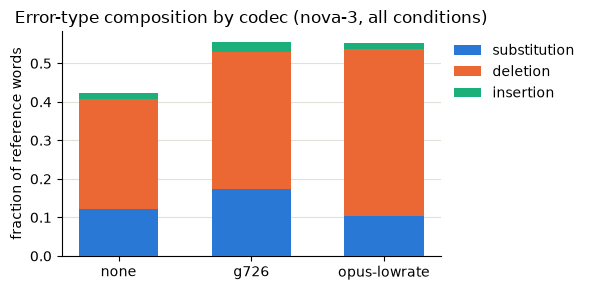

g726 -> substitutions (destroys entities in place); opus-lowrate -> deletions
(kills words outright). Same factor family, two different mechanisms.


In [8]:
def edit_composition(factor: str, model: str = "nova-3") -> pd.DataFrame:
    '''Sub/del/ins as a fraction of reference words, aggregated over every row
    at each level of `factor` (word counts summed first, then divided -- not a
    mean of per-row rates, so long/short clips are weighted by their word count).'''
    d = master[(master.model == model) & (~master.failed)]
    g = d.groupby(factor).agg(n_ref=("n_ref", "sum"), n_sub=("n_sub", "sum"),
                              n_del=("n_del", "sum"), n_ins=("n_ins", "sum")).reset_index()
    for col in ("sub", "del", "ins"):
        g[f"{col}_rate"] = g[f"n_{col}"] / g["n_ref"]
    return g


for factor in ["rt60", "noise_type", "codec", "mic_rolloff"]:
    print(edit_composition(factor)[[factor, "sub_rate", "del_rate", "ins_rate"]].round(3).to_string(index=False))
    print()

fig, ax = plt.subplots(figsize=(6, 3))
g = edit_composition("codec").set_index("codec").loc[["none", "g726", "opus-lowrate"]]
colors = {"sub_rate": "#2a78d6", "del_rate": "#eb6834", "ins_rate": "#1baf7a"}  # dataviz skill categorical slots 1/2/3
bottom = np.zeros(len(g))
for col, label in [("sub_rate", "substitution"), ("del_rate", "deletion"), ("ins_rate", "insertion")]:
    ax.bar(g.index, g[col], bottom=bottom, color=colors[col], label=label, width=0.6, zorder=3)
    bottom += g[col].values
ax.set_ylabel("fraction of reference words")
ax.set_title("Error-type composition by codec (nova-3, all conditions)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("g726 -> substitutions (destroys entities in place); opus-lowrate -> deletions")
print("(kills words outright). Same factor family, two different mechanisms.")

## Q: Is the rt60 non-monotonicity present within a single noise type?

In [9]:
for nt in ["babble", "engine", "road"]:
    d = master[(master.model == "nova-3") & (master.noise_type == nt)]
    per_clip = d.pivot_table(index="clip_id", columns="rt60", values="wer", aggfunc="mean")
    print(f"{nt:8s} rt60 -> WER:  {dict(per_clip.mean().round(3))}")

print()
print("babble spans all 4 measured rooms -> the dip at rt60=0.7 is a real, testable claim.")
print("engine/road only ever hit 2 of the 4 rooms -> monotonic by construction, not a test.")

d = master[(master.model == "nova-3") & (master.noise_type == "babble")]
piv = d.pivot_table(index="clip_id", columns="rt60", values="wer", aggfunc="mean")
dip = (piv[0.45] + piv[1.0]) / 2 - piv[0.7]
lo, hi = bootstrap_ci(dip.values)
print(f"babble dip depth at rt60=0.7 (vs the average of its neighbors): {dip.mean():.3f}  CI [{lo:.3f}, {hi:.3f}]")

babble   rt60 -> WER:  {0.2: np.float64(0.203), 0.45: np.float64(0.636), 0.7: np.float64(0.449), 1.0: np.float64(0.758)}
engine   rt60 -> WER:  {0.45: np.float64(0.308), 1.0: np.float64(0.551)}
road     rt60 -> WER:  {0.45: np.float64(0.444), 1.0: np.float64(0.728)}

babble spans all 4 measured rooms -> the dip at rt60=0.7 is a real, testable claim.
engine/road only ever hit 2 of the 4 rooms -> monotonic by construction, not a test.
babble dip depth at rt60=0.7 (vs the average of its neighbors): 0.247  CI [0.228, 0.268]


## Q: Which conditions have the largest gap between entity error rate and WER?

In [10]:
def entity_gap_table(model: str = "nova-3") -> pd.DataFrame:
    d = master[(master.model == model) & (~master.failed)].copy()

    def eer(row):
        spec = task_specs.get(row["clip_id"])
        if spec is None or not spec.slots:
            return np.nan
        txt = row["transcript"] if isinstance(row["transcript"], str) else ""
        return evaluate_task(txt, spec)["entity_error_rate"]

    d["entity_error_rate"] = d.apply(eer, axis=1)
    g = d.groupby("condition_name").agg(
        mean_wer=("wer", "mean"), mean_eer=("entity_error_rate", "mean"),
        rt60=("rt60", "first"), snr_db=("snr_db", "first"), noise_type=("noise_type", "first"),
        codec=("codec", "first"), mic_rolloff=("mic_rolloff", "first")).reset_index()
    g["gap"] = g["mean_eer"] - g["mean_wer"]
    return g.sort_values("gap", ascending=False).reset_index(drop=True)


egt = entity_gap_table()
print(egt.head(10)[["condition_name", "mean_wer", "mean_eer", "gap"]].round(3).to_string(index=False))
print()
overall_wer = master[(master.model == "nova-3") & (~master.failed)]["wer"].mean()
print(f"overall: mean WER = {overall_wer:.3f}   mean entity_error_rate = {egt['mean_eer'].mean():.3f}")
print("Entities are lost faster than words in general -- the whole point of scoring")
print("them separately (see report/writeup.md D2).")

                             condition_name  mean_wer  mean_eer   gap
rt60-0.45_snr-20_babble_opus-lowrate_roll-1     0.395     0.675 0.280
          rt60-0.2_snr-5_babble_g726_roll-1     0.411     0.688 0.277
      rt60-0.45_snr-10_babble_none_roll-0.5     0.388     0.662 0.274
rt60-0.2_snr-0_babble_opus-lowrate_roll-0.5     0.336     0.600 0.264
      rt60-0.45_snr-20_babble_g726_roll-0.5     0.257     0.512 0.255
         rt60-0.7_snr-10_babble_none_roll-1     0.524     0.775 0.251
          rt60-0.45_snr-10_road_none_roll-1     0.377     0.625 0.248
         rt60-1_snr-10_babble_none_roll-0.5     0.371     0.612 0.241
rt60-0.45_snr-20_babble_opus-lowrate_roll-0     0.172     0.412 0.241
         rt60-0.2_snr-10_babble_none_roll-1     0.092     0.325 0.233

overall: mean WER = 0.511   mean entity_error_rate = 0.633
Entities are lost faster than words in general -- the whole point of scoring
them separately (see report/writeup.md D2).


## Q: Show me a specific clip's transcript degrading across a factor sweep.

`u17` ("the serial number is Q9J05" — a spelled alphanumeric code) swept across
`rt60` with everything else pinned at a harsh corner (SNR 5 dB, babble,
opus-lowrate, full mic rolloff).

In [11]:
sweep("u17", "rt60", {"snr_db": 5.0, "noise_type": "babble", "codec": "opus-lowrate", "mic_rolloff": 1.0})

rt60=   0.2  WER=0.333  conf=0.950  hyp='the serial number is two nine eight zero five'
rt60=  0.45  WER=1.000  conf=  --    hyp='(empty)'
rt60=   0.7  WER=1.000  conf=  --    hyp='(empty)'
rt60=   1.0  WER=1.000  conf=  --    hyp='(empty)'


## Bonus: what are the named headline dead-zone conditions?

Straight from `results/dead_zones.csv` — the D1 headline deliverable
(confidently wrong: high confidence, high WER), ranked by gap.

In [12]:
dz = dead_zones[(dead_zones.category == "dead_zone") & (dead_zones.model == "nova-3")]
dz = dz.sort_values("gap", ascending=False)
dz.head(8)[["condition_name", "mean_conf", "wer_spoke", "gap", "n_silent"]].round(3)

,condition_name,mean_conf,wer_spoke,gap,n_silent
9,rt60-0.45_snr-0_engine_g726_roll-0,0.829,0.306,0.136,0
10,rt60-0.2_snr-0_babble_opus-lowrate_roll-0.5,0.807,0.319,0.126,1


## Bonus: how do the arms compare on the clips they share?

**Do not just `.groupby('model')['wer'].mean()` this** — see the facts cell at
the top. Raw `wer` isn't comparable across models because of a formatting
mismatch (spelled-out digits vs raw digits + punctuation), not just an
acoustic one. This cell shows the naive number, why it's wrong, and the fixed
number from the precomputed cross-model normalization.

**`elevenlabs-scribe` is deliberately absent from the fixed comparison.**
Normalization can only remove a *constant* offset; Scribe's orthography is a
per-call draw, so there is no single offset to subtract (facts cell, bullet 3).
The cell reads the comparability verdict out of `results/model_arms.json`
rather than hardcoding a model list, so a fourth arm lands on the correct side
of the line automatically — and Scribe is shown as *explicitly excluded with
its reason printed*, never silently dropped.

In [13]:
import textwrap

with open(ROOT / "results" / "model_arms.json") as f:
    model_arms = json.load(f)

comparable = model_arms["wer_comparability"]["comparable"]
excluded = model_arms["wer_comparability"]["excluded"]

# Clips common to EVERY arm, not just whisper's -- with a third arm on its own
# subset, keying off one model would silently widen the comparison.
shared_clips = sorted(set.intersection(
    *(set(g["clip_id"].unique()) for _, g in master.groupby("model"))))
d = master[master.clip_id.isin(shared_clips) & (~master.failed)]
print(f"{master['model'].nunique()} arms; clips common to all of them: {len(shared_clips)}")
print()

print("RAW pipeline `wer` (misleading for a cross-model claim):")
for m, v in d.groupby("model")["wer"].mean().items():
    tag = "   <- EXCLUDED from cross-model WER" if m in excluded else ""
    print(f"  {m:18s} {v:.3f}{tag}")
print()

print("Cross-model-normalized (deadzone/cross_model_norm.py applies Whisper's own")
print("EnglishTextNormalizer + digit-run splitting to BOTH comparable arms;")
print("from results/model_arms.json):")
for m in comparable:
    s = model_arms["normalization_shift"][m]
    print(f"  {m:18s} strict={s['wer_strict_mean']:.3f}  crossmodel={s['wer_crossmodel_mean']:.3f}"
          f"  shift={s['mean_shift']:+.3f}  (n={s['n_rows']})")
print()

for m in excluded:
    s = model_arms["normalization_shift"][m]
    print(f"  {m}: normalized WER {s['wer_crossmodel_mean']:.3f} is COMPUTABLE but NOT")
    print(f"  COMPARABLE, and is not reported as a rank. Reason:")
    print(textwrap.fill(s["wer_incomparable_reason"], 74,
                        initial_indent="    ", subsequent_indent="    "))
print()

from deadzone.cross_model_norm import cross_model_classify_errors
ref = manifest.set_index("id").loc["u02", "ground_truth"]
row = master[(master.model == "whisper-base") & (master.clip_id == "u02")
            & (master.condition_name == "rt60-0.2_snr-0_babble_none_roll-0")].iloc[0]
r = cross_model_classify_errors(ref, row["transcript"])
print(f"example -- ref: {ref!r}")
print(f"           hyp: {row['transcript']!r}")
print(f"           pipeline wer (unfair): {row['wer']:.3f}   cross_model wer (fair): {r['wer']:.3f}")

3 arms; clips common to all of them: 10

RAW pipeline `wer` (misleading for a cross-model claim):
  elevenlabs-scribe  0.410   <- EXCLUDED from cross-model WER
  nova-3             0.433
  whisper-base       0.996

Cross-model-normalized (deadzone/cross_model_norm.py applies Whisper's own
EnglishTextNormalizer + digit-run splitting to BOTH comparable arms;
from results/model_arms.json):
  nova-3             strict=0.433  crossmodel=0.447  shift=-0.014  (n=1757)
  whisper-base       strict=0.996  crossmodel=0.906  shift=+0.090  (n=1757)

  elevenlabs-scribe: normalized WER 0.346 is COMPUTABLE but NOT
  COMPARABLE, and is not reported as a rank. Reason:
    orthography is NON-DETERMINISTIC across identical calls. Four repeat
    calls on byte-identical audio returned different transcripts on 5 of 6
    probe clips: `A7X42` vs `A seven X four two`, `Q9J05.` vs `Q nine J
    zero five.`, and u33 flips the OTHER way (`one Z nine nine A W five.`
    3x, `1Z99AW5.` 1x). Worth up to 0.727 stri

example -- ref: 'call maria at four zero five nine one two seven seven'
           hyp: 'Call Maria 405-912-717.'
           pipeline wer (unfair): 0.818   cross_model wer (fair): 0.182


## Bonus: the one cross-arm comparison Scribe IS allowed in — confidence *shape*

WER can't be ranked across arms, but the **shape** of confidence-vs-error can:
it is a rank correlation computed *within* each arm against that arm's own
confidence distribution, so no cross-vendor confidence scale is ever assumed.
This is the "rank-only" half of Scribe's treatment.

It is also where this notebook's standing rule earns its keep: **every
confidence aggregate is reported next to `n_spoke` / `n_silent`.** A silent clip
carries no confidence at all, so a correlation computed naively over "all
conditions" pairs a confidence mean taken over the *speaking* clips with a WER
taken over *every* clip — two different populations subtracted as if they were
one. `SPEC.md` Appendix G records that exact mismatch as the defect that cost
the project its original headline, so the guard stays on every arm, new ones
included.

In [14]:
from scipy.stats import spearmanr

# Use the CANONICAL per-condition aggregation -- the same function that produced
# results/confidence_gap.txt and results/dead_zones.csv. A hand-rolled groupby
# here looked right and landed whisper at -0.585 against the artifact's -0.590:
# small, but it is exactly the "notebook drifts from results/" failure this repo
# has hit five times. Call the shipped code path instead of re-deriving it.
from deadzone.analysis.confidence_gap import per_condition_table


def conf_shape_by_arm() -> pd.DataFrame:
    '''Per-arm spearman(mean_conf, WER) computed on the SAME population -- the
    clips that actually emitted words -- with the silence census beside it.
    Conditions where the arm spoke on NO clip (mute zones) have no confidence
    at all, so they are held out and COUNTED, never folded in as a quiet zero.'''
    out = []
    for m, g in master.groupby("model"):
        t = pd.DataFrame(per_condition_table(g[~g.failed].to_dict("records")))
        ok = t.dropna(subset=["mean_conf", "wer_spoke"])
        out.append({
            "model": m,
            "rho_conf_vs_wer": round(float(spearmanr(ok["mean_conf"], ok["wer_spoke"]).statistic), 3),
            "n_cond_usable": len(ok),
            "n_cond_mute": len(t) - len(ok),
            "n_spoke": int(t["n_spoke"].sum()),
            "n_silent": int(t["n_silent"].sum()),
            "n_conf_without_words": int(t["n_conf_without_words"].sum()),
            "n_clips": int(g["clip_id"].nunique()),
        })
    return pd.DataFrame(out)


print(conf_shape_by_arm().to_string(index=False))
print()
print("`n_conf_without_words` is the anomaly from the facts cell: rows carrying a")
print("confidence on ZERO scorable words. All 5 are whisper-base (the u11 glyphs).")
print()
print("Rank-only, so elevenlabs-scribe belongs here even though it is barred from")
print("cross-model WER. NOTE THE SCOPE: nova-3 is over 40 clips, the other two over")
print("10, so this is not a like-for-like league table -- see results/model_arms.txt")
print("for all three restricted to the common 10 clips (nova-3 reads -0.970 there).")
print()
print("The scoring caveat that matters more than the ranking: these are STRICT")
print("scores. Under cross-model orthography normalization scribe moves -0.820 ->")
print("-0.948 while nova-3 is unmoved at -0.970 -- i.e. the apparent gap between the")
print("two COMMERCIAL arms is mostly a scoring artifact, and ~0.02 is an upper bound")
print("(measurement error only attenuates |rho|). Whisper is the real outlier, at")
print("-0.59 strict / -0.60 normalized. Caveat: n=3 arms and only ONE open model, so")
print("'commercial vs open' and 'vendor-specific' stay confounded.")

            model  rho_conf_vs_wer  n_cond_usable  n_cond_mute  n_spoke  n_silent  n_conf_without_words  n_clips
elevenlabs-scribe            -0.82            174            2     1682        78                     0       10
           nova-3            -0.98            169            7     4830      2210                     0       40
     whisper-base            -0.59            171            5     1426       336                     5       10

`n_conf_without_words` is the anomaly from the facts cell: rows carrying a
confidence on ZERO scorable words. All 5 are whisper-base (the u11 glyphs).

Rank-only, so elevenlabs-scribe belongs here even though it is barred from
cross-model WER. NOTE THE SCOPE: nova-3 is over 40 clips, the other two over
10, so this is not a like-for-like league table -- see results/model_arms.txt
for all three restricted to the common 10 clips (nova-3 reads -0.970 there).

The scoring caveat that matters more than the ranking: these are STRICT
scores. Under c